# 05 — Machine Learning Analysis

## Objective

Assess the relationship between climate and tourism using non-parametric models.

---

## Data

- Final dataset (Notebook 03)
- NUTS2 regions (2010–2023)

---

## Method

- Decision Tree (interpretability)  
- Random Forest (predictive performance)  
- Feature importance and partial dependence  

---

## Output

- Model performance (OOB R², RMSE)  
- Feature importance  
- Partial dependence plots  

---

In [3]:
import pandas as pd
import numpy as np

# load data
df = pd.read_csv("../data/processed/final_dataset_nuts2_2010_2023.csv")

# recreate logs (CRITICAL)
df = df[
    (df["tourism_nights"] > 0) &
    (df["gdp"] > 0) &
    (df["population"] > 0)
].copy()

df["log_tourism"] = np.log(df["tourism_nights"])
df["log_gdp"] = np.log(df["gdp"])
df["log_pop"] = np.log(df["population"])

# ML dataset
df_ml = df.copy()

# reset index if needed
if isinstance(df_ml.index, pd.MultiIndex):
    df_ml = df_ml.reset_index()

# same transformations as your original code
df_ml["gdp_k"] = np.exp(df_ml["log_gdp"]) / 1000
df_ml["tourism_m"] = np.exp(df_ml["log_tourism"]) / 1e6

In [9]:
print(df_ml.shape)
print(df_ml.columns)

(3274, 13)
Index(['region', 'year', 'tourism_nights', 'gdp', 'population', 'temperature',
       'precipitation', 'log_tourism', 'log_gdp', 'log_pop', 'gdp_k',
       'tourism_m', 'pop'],
      dtype='object')


In [4]:
features = ["gdp_k", "temperature", "precipitation"]

X = df_ml[features]
y = df_ml["tourism_m"]

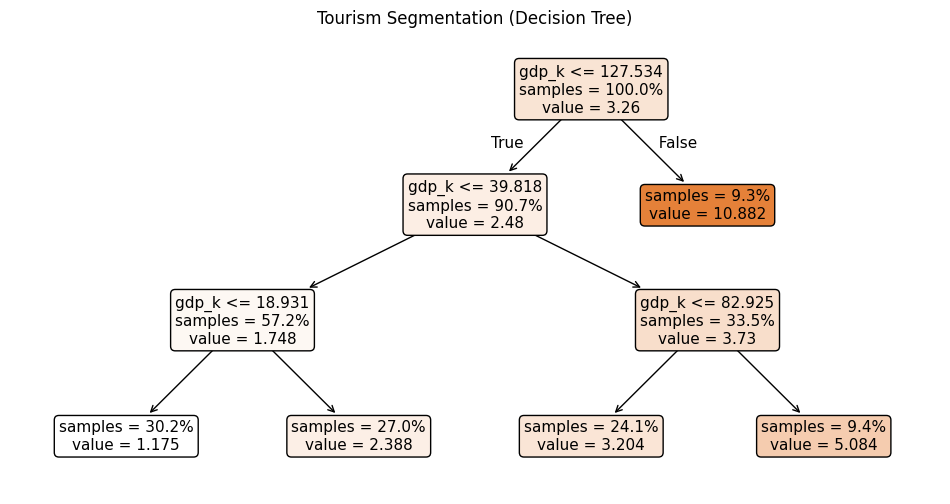

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

tree = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=300,
    random_state=42
)

tree.fit(X, y)

fig, ax = plt.subplots(figsize=(12,6))

plot_tree(
    tree,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=False,
    proportion=True,
    ax=ax
)

ax.set_title("Tourism Segmentation (Decision Tree)")
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

print("OOB R²:", rf.oob_score_)

y_oob = rf.oob_prediction_

rmse = np.sqrt(mean_squared_error(y, y_oob))
print("OOB RMSE:", rmse)

OOB R²: 0.6585089695622652
OOB RMSE: 2.4366919612169355


In [7]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(rf, X, y, n_repeats=10, random_state=42)

perm_imp = pd.Series(perm.importances_mean, index=X.columns)
print(perm_imp.sort_values(ascending=False))

gdp_k            1.201167
temperature      0.223366
precipitation    0.194594
dtype: float64


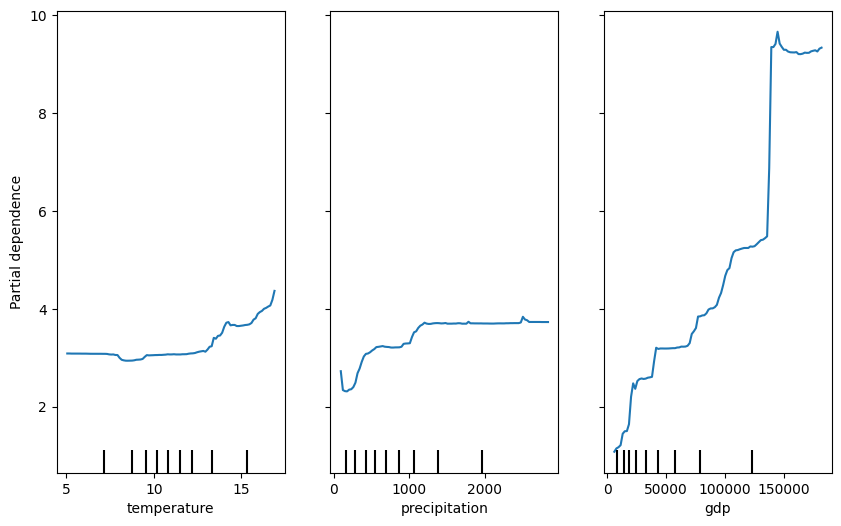

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

df_ml["gdp"] = np.exp(df_ml["log_gdp"])
df_ml["pop"] = np.exp(df_ml["log_pop"])

features = ["gdp", "pop", "temperature", "precipitation"]

X = df_ml[features]
y = df_ml["tourism_m"]

rf.fit(X, y)

fig, ax = plt.subplots(figsize=(10,6))

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    ["temperature", "precipitation", "gdp"],
    ax=ax
)

plt.show()